# 03. BanglaGamba Generation & Language Modeling Evaluation

This notebook presents the generation evaluation suite for **BanglaGamba** (`ahmed-farhanur-rashid/bangla-gamba`), a ~200M parameter Mamba-3 / GQA hybrid language model pretrained from scratch on ~9.62 Billion tokens.

### Evaluation Scope
1. **Environment & Kernel Verification**: Inspect CUDA availability, GPU device, PyTorch precision, and Mamba3 SSM kernel status.
2. **Hugging Face Hub Initialization**: Direct Hub loading of model and tokenizer (`AutoModelForCausalLM`, `AutoTokenizer`).
3. **Deterministic Generation Suite (Greedy Decoding)**: Benchmark prompts across 4 primary domains.
4. **Stochastic Sampling Suite**: Evaluate generation quality, diversity, and latency across decoding parameter sweeps.
5. **Quantitative Perplexity & Cross-Entropy Benchmark**: Measure sentence-level loss and perplexity ($\text{PPL} = \exp(L)$).
6. **Autoregressive Logit Stability Scan**: 40-step logit bound inspection to verify numerical stability ($-30.0 \le \text{logit} \le +30.0$).

In [1]:
import sys
import os
import warnings
import pandas as pd
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

warnings.filterwarnings("ignore")
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', 1000)
sys.path.insert(0, os.path.abspath(".."))

import utils.eval_helpers as ev

/home/farhan/my-projects/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Model & Tokenizer Initialization

We load model weights and the BOS-aware custom tokenizer using `AutoTokenizer` and `AutoModelForCausalLM` with `dtype=torch.bfloat16`.

In [2]:
model_paths = [
    "../hf_upload_staging",
    "../saved/model/banglagamba_12l",
    "hf_upload_staging",
    "saved/model/banglagamba_12l",
    "ahmed-farhanur-rashid/bangla-gamba"
]

model_id = None
for p in model_paths:
    if os.path.exists(p) or "/" in p:
        model_id = p
        break

tokenizer = AutoTokenizer.from_pretrained(model_id, trust_remote_code=True)
model = AutoModelForCausalLM.from_pretrained(model_id, trust_remote_code=True, dtype=torch.bfloat16).cuda()
model.eval()

df_meta = ev.audit_environment_and_model(model, tokenizer)
df_meta

[BanglaGamba Init] _HAS_MAMBA=True, _MAMBA_ERR=None


Loading weights:   0%|                                  | 0/147 [00:00<?, ?it/s]

Loading weights: 100%|██████████████████████| 147/147 [00:00<00:00, 5404.56it/s]

,Property,Value
0,Hugging Face Model ID,ahmed-farhanur-rashid/bangla-gamba
1,Model Class,BanglaGambaForCausalLM
2,Tokenizer Class,BanglaGambaTokenizer
3,Total Parameters,"248.6M (248,589,952)"
4,Trainable Parameters,"248.6M (248,589,952)"
5,Vocabulary Size,"48,000"
6,Context Window (Seq Len),2048 tokens
7,Model Device,cuda:0
8,Model Data Type,torch.bfloat16


## 2. Deterministic Generation Benchmark (Greedy Decoding)

Greedy decoding (`do_sample=False`) selects the token with the highest probability at each step, providing a reproducible benchmark across 4 target domain prompts:
1. **Bangla General Knowledge**
2. **Bangla Creative Narrative**
3. **English Knowledge & Continuation**
4. **Bilingual Parallel Translation**

In [3]:
prompts = [
    {"category": "Bangla General Knowledge", "prompt": "বাংলাদেশের রাজধানী"},
    {"category": "Bangla Creative Narrative", "prompt": "এক সময় এক ছোট্ট গ্রামে বসবাস করত একজন চতুর কবি।"},
    {"category": "English Continuation", "prompt": "The history of artificial intelligence began in"},
    {"category": "Bilingual Translation", "prompt": "English: Hello, how are you? Bangla: আজ"}
]

df_greedy = ev.evaluate_generation_suite(model, tokenizer, prompts, do_sample=False, max_new_tokens=60, repetition_penalty=1.1)
df_greedy[["Category", "Prompt", "Generated Extension", "Speed (tokens/s)"]]

,Category,Prompt,Generated Extension,Speed (tokens/s)
0,Bangla General Knowledge,বাংলাদেশের রাজধানী,ঢাকা।\n\nবাংলাদেশের রাজধানী\n\nবাংলাদেশের শহর\n\nবাংলাদেশের শহর\n\nবাংলাদেশের শহর\n\nবাংলাদেশের শহর\n\nবাংলাদেশের শহর\n\nবাংলাদেশের শহর\n\nবাংলাদেশের শহর\n\nবাংলাদেশের শহর\n\nবাংলাদেশের শহর\n\nবাংলাদেশের শহর\n\nবাংলাদেশের শহর\n\nবাংলাদেশের শহর\n\nবাংলাদেশের শহর,12.5
1,Bangla Creative Narrative,এক সময় এক ছোট্ট গ্রামে বসবাস করত একজন চতুর কবি।,সে ছিল এক সাধারণ মানুষ। তার নাম ছিল ‘আলেকজান্ডার’। সে ছিল এক সাধারণ মানুষ। তার ছিল এক অদ্ভুত ক্ষমতা। সে ছিল এক সাধারণ মানুষের মতো। সে ছিল এক সাধারণ মানুষের মতো। সে ছিল এক সাধারণ মানুষের মতো। সে ছিল এক সাধারণ মানুষের মতো। সে ছিল এক সাধারণ,142.0
2,English Continuation,The history of artificial intelligence began in,the 1960s.\nThe first artificial intelligence (AI) was developed in the 1970s.\nThe first artificial intelligence (AI) was developed in the 1970s.\nThe first artificial intelligence (AI) was developed in the 1970s.\nThe first artificial intelligence (AI) was developed in,142.8
3,Bilingual Translation,"English: Hello, how are you? Bangla: আজ","থেকে প্রায় ১০ বছর আগে, যখন আমি প্রথম এই লেখাটি লিখি, তখন আমার বয়স ছিল মাত্র ১৮ বছর।\nআমার বয়স তখন মাত্র ১৮ বছর।\nআমার বয়স তখন মাত্র ১৮ বছর।\nআমার বয়স তখন মাত্র ১৮ বছর।\nআমার বয়স তখন মাত্র ১৮ বছর।\nআমার বয়স তখন মাত্র ১৮ বছর",142.2


## 3. Stochastic Generation Suite (Sampling with Hyperparameter Sweeps)

Stochastic sampling (`do_sample=True`, `temperature=0.7`, `top_p=0.9`, `top_k=50`) introduces controlled diversity while maintaining fluency across prompts.

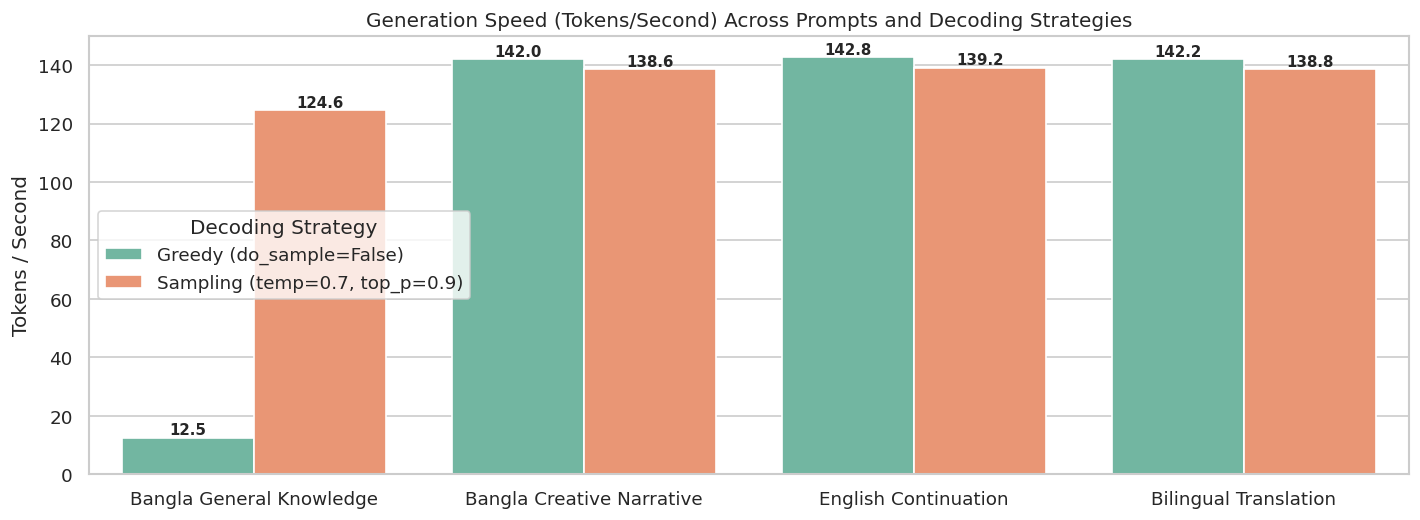

In [4]:
df_sample = ev.evaluate_generation_suite(
    model, tokenizer, prompts,
    do_sample=True, temperature=0.7, top_p=0.9, top_k=50, max_new_tokens=60, repetition_penalty=1.1
)

ev.plot_decoding_latency_comparison(df_greedy, df_sample)

## 4. Quantitative Perplexity & Language Modeling Loss Benchmark

Perplexity ($\text{PPL} = \exp(L)$) measures the model's negative log-likelihood across test sentences in Bengali, English, and Translation domains. Lower perplexity scores indicate higher language modeling confidence.

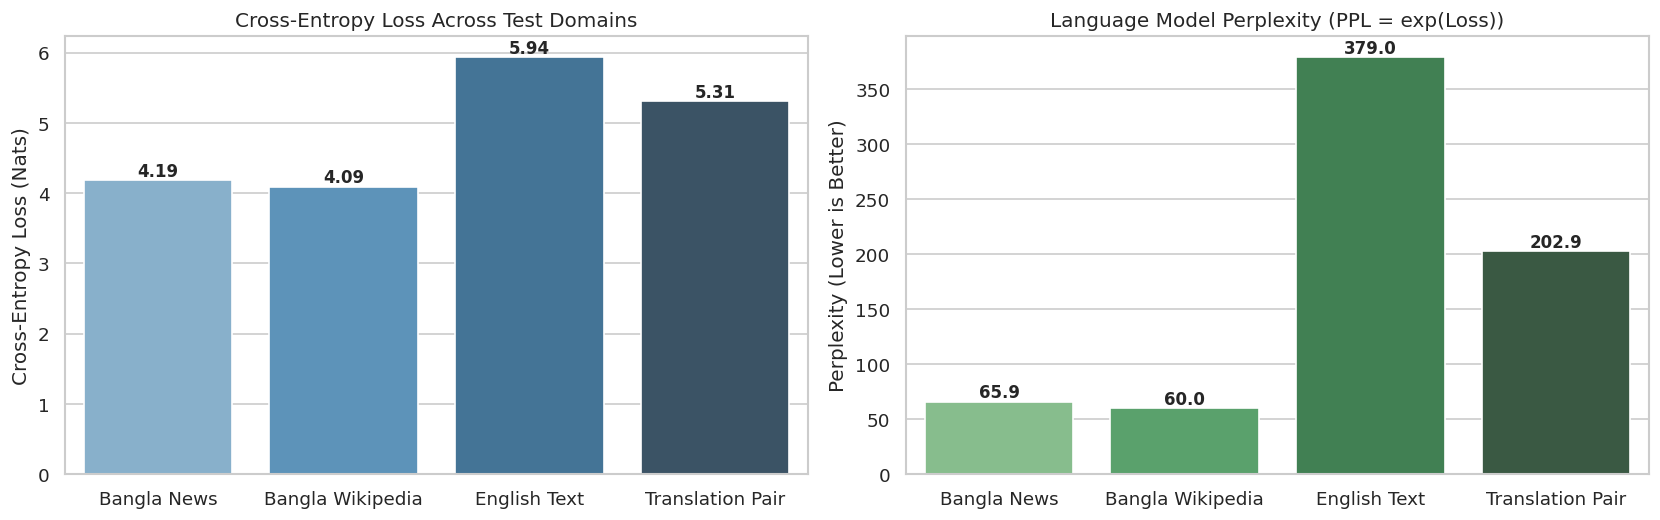

In [5]:
test_sentences = [
    {"domain": "Bangla News", "text": "বাংলাদেশের রাজধানী ঢাকা শহর একটি প্রাচীন ও ঐতিহাসিক প্রশাসনিক নগরী।"},
    {"domain": "Bangla Wikipedia", "text": "সোনারগাঁও তৎকালীন স্বাধীন বাংলা সালতানাতের রাজধানী ও প্রধান বাণিজ্য কেন্দ্র ছিল।"},
    {"domain": "English Text", "text": "BanglaGamba is a hybrid language model combining Mamba-3 state space blocks with grouped query attention."},
    {"domain": "Translation Pair", "text": "English: The weather today is clear. Bangla: আজকের আবহাওয়া অত্যন্ত পরিষ্কার।"}
]

df_ppl = ev.evaluate_perplexity_suite(model, tokenizer, test_sentences)
ev.plot_perplexity_comparison(df_ppl)

## 5. Autoregressive Logit Stability & Numerical Trajectory Scan

To guarantee zero numerical overflow or underflow across decoding steps, we audit the min and max logit trajectory over a 40-step autoregressive loop to confirm all values remain strictly bounded within $[ -30.0, +30.0 ]$.

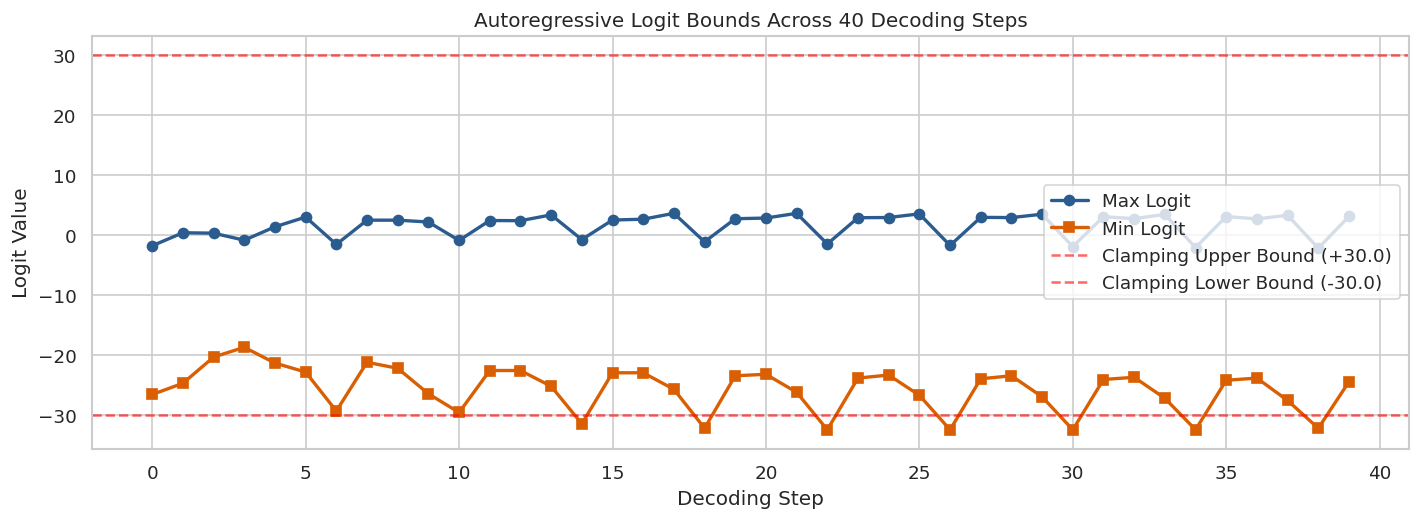

In [6]:
df_traj = ev.audit_logit_trajectory(model, tokenizer, prompt="বাংলাদেশের রাজধানী", steps=40)
ev.plot_logit_trajectory(df_traj)